# Smart Agriculture AI-Assisted Labeling Project

## 1. Data Understanding (데이터 이해)

### DU-01. Project & Dataset Overview (프로젝트 및 데이터셋 개요)

본 프로젝트는 Smart Agriculture(스마트 농업) 환경의 작물 및 잡초 이미지를 활용하여 
Computer Vision(컴퓨터 비전) 기반 데이터 라벨링 과정을 수행하는 것을 목적으로 한다.

기존의 Manual Labeling(수동 라벨링)뿐만 아니라 AI-Assisted Labeling(AI 보조 라벨링)과 
Auto Labeling(자동 라벨링)을 함께 적용하여 라벨링 방식에 따른 품질과 작업 효율성을 비교한다. 

프로젝트에서는 CropAndWeed Dataset(작물 및 잡초 데이터셋)을 활용하며,
실제 농경지에서 촬영된 이미지와 기존 Ground Truth(정답 라벨)를 기반으로 
Crop(작물)과 Weed(잡초)의 객체 및 영역 정보를 분석한다. 

### Project Objectives (프로젝트 목표)

- Smart Agriculture Image(스마트 농업 이미지)의 구조와 객체 특성을 이해한다.
- Crop(작물)과 Weed(잡초)를 대상으로 Segmentation Labeling(분할 라벨링)을 수행한다.
- Manual Labeling(수동 라벨링)과 AI-Assisted Labeling(AI 보조 라벨링)을 비교한다.
- Auto Labeling(자동 라벨링) 결과에 Human Review(사람 검수)를 적용한다.
- Ground Truth(정답 라벨)를 활용하여 IoU(Intersection over Union) 등의 품질 지표를 평가한다.
- 이미지 및 객체 난이도에 따른 Auto Labeling 성능 차이를 분석한다.
- 라벨링 품질과 작업시간을 함께 측정하여 AI 활용에 따른 생산성 변화를 평가한다.


### Dataset Overview (데이터셋 개요)

본 프로젝트에서는 CropAndWeed Dataset을 사용한다. 

CropAndWeed Dataset은 실제 농업 환경에서 촬영된 Crop(작물)과 Weed(잡초) 이미지로 구성되어 있으며,
객체 탐지 및 이미지 분할 연구를 위한 다양한 Annotation(라벨) 정보를 제공한다.

본 프로젝트에서 확인할 주요 데이터 구성은 다음과 같다.

- `images/` : 원본 RGB Image(이미지)
- `bboxes/` : Bounding Box(바운딩 박스) 라벨
- `labelIds/` : Pixel-level Label(픽셀 단위 라벨)
- `params/` : 이미지 및 객체 관련 Parameter(파라미터)

전체 Dataset을 그대로 라벨링에 사용하는 대신 Data Understanding(데이터 이해)을 통해
이미지와 객체의 특성을 분석한 후 Pilot Dataset(파일럿 데이터셋)을 선정한다.

선정된 이미지는 이후 Manual Labeling, AI-Assisted Labeling 및 Auto Labeling 실험에 활용한다. 

### DU-02. Dataset Directory Structure (데이터셋 디렉터리 구조)

CropAndWeed Dataset의 Raw Data(원본 데이터)가 정상적으로 구성되어 있는지 확인한다. 

주요 디렉터리의 존재 여부와 각 디렉터리에 포함된 파일 수를 확인하여 
이후 Data Understanding(데이터의 이해) 및 라벨링에 사용할 데이터 구조를검증한다.

확인 대상은 다음과 같다. 

- `images/` : 원본 RGB Image(이미지)
- `bboxes/` : Bounding Box(바운딩 박스) 정보
- `labelIds/` : Pixel-level Label(픽셀 단위 라벨)
- `params/` : 이미지 및 객체 관련 Parameter(파라미터)

In [1]:
from pathlib import Path

# Project paths
PROJECT_ROOT = Path("..")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Main dataset directories
dataset_dirs = {
    "images": RAW_DATA_DIR / "images",
    "bboxes": RAW_DATA_DIR / "bboxes",
    "labelIds": RAW_DATA_DIR / "labelIds",
    "params": RAW_DATA_DIR / "params",
}

print("=== Dataset Directory Check ===")

for name, path in dataset_dirs.items():
    exists = path.exists()
    file_count = sum(1 for p in path.rglob("*") if p.is_file()) if exists else 0

    print(f"{name:<10} | Exists: {str(exists):<5} | Files: {file_count:,}")

=== Dataset Directory Check ===
images     | Exists: True  | Files: 8,034
bboxes     | Exists: True  | Files: 8,034
labelIds   | Exists: True  | Files: 8,034
params     | Exists: True  | Files: 8,034


In [2]:
from collections import Counter
extension_counts = Counter(
    p.suffix.lower()
    for p in RAW_DATA_DIR.rglob("*")
    if p.is_file()
)

print("=== File Extension Distribution ===")

for ext, count in extension_counts.most_common():
    label = ext if ext else "[no extension]"
    print(f"{label:<10} : {count:,}")

=== File Extension Distribution ===
.csv       : 17,055
.jpg       : 8,034
.png       : 8,034
.txt       : 2


#### Observation

- CropAndWeed Dataset의 주요 디렉터리인 `images`, `bboxes`, `labelIds`, `params`가 모두 정상적으로 확인되었다.
- 각 디렉터리에는 **8,034개의 파일**이 존재하며, 원본 이미지와 주요 Annotation(라벨) 데이터가 단위로 대응되는 구조임을 확인하였다.
- 원본 RGB Image(이미지)는 총 **8,034장의 JPG 파일**로 구성되어 있으며, Pixel-level Label(픽셀 단위 라벨)에 사용되는 PNG 파일 역시 **8,034개**가 존재한다. 
- 전체 Raw Data(원본 데이터)에서는 CSV 파일 **17,055개**, JPG 파일 **8,034개**, PNG 파일 **8,034개**, TXT 파일 **2개**가 확인되었다. 
- 디렉터리별 파일 수가 동일하다는 점에서 Image-Annotation Mapping(이미지-라벨 연결 구조)이 이미지 단위로 구성되어 있을 가능성이 높으며, 다음 단계에서 실제 파일명을 
  비교하여 이를 검증한다. 

### DU-03. Image-Annotation Mapping (이미지-라벨 연결 구조)

CropAndWeed Dataset의 원본 이미지와 Annotation(라벨) 데이터가 어떤 방식으로 연결되는지 확인한다. 

각 디렉터리의 파일 형식과 파일며을 비교하여 동일한 Image ID(이미지 ID)를 기준으로 
RGB Image(원본 이미지), Bounding Box(바운딩 박스), Pixel-level Label(픽셀 단위 라벨),
Parameter(파라미터)가 연결되는지 검증한다. 

In [3]:
# Check file extensions in each dataset directory

print("=== File Types by Directory ===")

for name, path in dataset_dirs.items():
    extensions = Counter(
        p.suffix.lower()
        for p in path.rglob("*")
        if p.is_file()
    )

    print(f"\n[{name}]")
    for ext, count in extensions.most_common():
        print(f"{ext:<8} : {count:,}")

=== File Types by Directory ===

[images]
.jpg     : 8,034

[bboxes]
.csv     : 8,034

[labelIds]
.png     : 8,034

[params]
.csv     : 8,034


In [4]:
# Display sample filenames from each directory

print("=== Sample Filenames ===")

for name, path in dataset_dirs.items():
    files = sorted(
        p for p in path.rglob("*")
        if p.is_file()
    )

    print(f"\n[{name}]")
    for file in files[:5]:
        print(file.name)

=== Sample Filenames ===

[images]
ave-0000-0001.jpg
ave-0000-0002.jpg
ave-0000-0005.jpg
ave-0007-0000.jpg
ave-0007-0007.jpg

[bboxes]
ave-0000-0001.csv
ave-0000-0002.csv
ave-0000-0005.csv
ave-0007-0000.csv
ave-0007-0007.csv

[labelIds]
ave-0000-0001.png
ave-0000-0002.png
ave-0000-0005.png
ave-0007-0000.png
ave-0007-0007.png

[params]
ave-0000-0001.csv
ave-0000-0002.csv
ave-0000-0005.csv
ave-0007-0000.csv
ave-0007-0007.csv


In [5]:
# Compare file stems across main dataset directories

file_stems = {}

for name, path in dataset_dirs.items():
    file_stems[name] = {
        p.stem
        for p in path.rglob("*")
        if p.is_file()
    }

print("=== Unique File Stem Counts ===")

for name, stems in file_stems.items():
    print(f"{name:<10} : {len(stems):,}")

# Compare image IDs with annotation directories
image_ids = file_stems["images"]

print("\n=== Image-Annotation ID Matching ===")

for name in ["bboxes", "labelIds", "params"]:
    matched = len(image_ids & file_stems[name])
    missing = len(image_ids - file_stems[name])

    print(
        f"{name:<10} | "
        f"Matched: {matched:,} | "
        f"Missing: {missing:,}"
    )

=== Unique File Stem Counts ===
images     : 8,034
bboxes     : 8,034
labelIds   : 8,034
params     : 8,034

=== Image-Annotation ID Matching ===
bboxes     | Matched: 8,034 | Missing: 0
labelIds   | Matched: 8,034 | Missing: 0
params     | Matched: 8,034 | Missing: 0


#### Observation

- `images`, `bboxes`, `labelIds`, `params` 디렉터리는 각각 **8,034개의 파일**로 구성되어 있다. 
- 원본 이미지는 JPG, Bounding Box(바운딩 박스)와 Parameter(파라미터)는 CSV, Pixel-level Label(픽셀 단위 라벨)은 PNG 형식으로 저장되어 있다. 
- 네 데이터 유형은 `ave-0000-0001`과 같은 동일한 Image Id(이미지 ID)를 File Stem(파일명 기준 ID)으로 사용하고 있다. 
- 전체 **8,034개 Image ID**를 비교한 결과, `bboxes`, `labelIds`, `params` 모두 원본 이미지와 **8,034개가 일치했으며 Missing ID(누락 ID)는 0개**로 확인되었다.
- 따라서 원본 이미지와 주요 Annotation(라벨) 데이터 사이에 완전한 **1:1 Image-Annotation Mapping(이미지-라벨 연결 구조)**이 구성되어 있음을 확인하였다. 

### DU-04. Image Dataset Inspection (이미지 데이터 점검)

CropAndWeed Dataset의 RGB Image(원본 이미지)를 직접 불러와 이미지의 기본적인 기술적 특성과 실제 농경지 환경을 확인한다. 

Image Resolution(이미지 해상도), Channel(채널), 데이터 형식 등을 점검하고,
여러 Sample Image(샘플 이미지)를 시각화하여 작물과 잡초의 크기, 밀집도, 배경 환경 등 
향후 Segmentation LabelingQ(분할 라벨링) 및 Auto Labeling(자동 라벨링)에 영향을 줄 수 있는 특징을 파악한다. 

In [6]:
import sys
print(sys.executable)

c:\Users\user\OneDrive\Documents\data-labeling-portfolio\.venv\Scripts\python.exe


In [7]:
import sys
print(sys.executable)

import cv2
print(cv2.__version__)

c:\Users\user\OneDrive\Documents\data-labeling-portfolio\.venv\Scripts\python.exe
5.0.0


In [8]:
import cv2

IMAGE_DIR = dataset_dirs["images"]

image_files = sorted(IMAGE_DIR.glob("*.jpg"))

print("=== Image Dataset Basic Check ===")
print(f"Total images : {len(image_files):,}")

# First sample image
sample_path = image_files[0]
sample_img = cv2.imread(str(sample_path))

print(f"\nSample file  : {sample_path.name}")
print(f"Shape        : {sample_img.shape}")
print(f"Data type    : {sample_img.dtype}")
print(f"Min value    : {sample_img.min()}")
print(f"Max value    : {sample_img.max()}")

=== Image Dataset Basic Check ===
Total images : 8,034

Sample file  : ave-0000-0001.jpg
Shape        : (1088, 1920, 3)
Data type    : uint8
Min value    : 0
Max value    : 255


In [9]:
from collections import Counter
resolution_counts = Counter()

for image_path in image_files:
    img = cv2.imread(str(image_path))

    if img is not None:
        height, width = img.shape[:2]
        resolution_counts[(width, height)] += 1

print("=== Image Resolution Distribution ===")
print(f"Unique resolutions: {len(resolution_counts)}")

for (width, height), count in resolution_counts.most_common():
    print(f"{width} × {height} : {count:,}")

=== Image Resolution Distribution ===
Unique resolutions: 1
1920 × 1088 : 8,034


In [10]:
channel_counts = Counter()

for image_path in image_files:
    img = cv2.imread(str(image_path), cv2.IMREAD_UNCHANGED)

    if img is None:
        channel_counts["Unreadable"] += 1
    elif img.ndim == 2:
        channel_counts["Grayscale"] += 1
    elif img.shape[2] == 3:
        channel_counts["3-channel"] += 1
    elif img.shape[2] == 4:
        channel_counts["4-channel"] += 1
    else:
        channel_counts[f"{img.shape[2]}-channel"] += 1

print("=== Image Channel Distribution ===")

for channel, count in channel_counts.items():
    print(f"{channel:<12} : {count:,}")

=== Image Channel Distribution ===
3-channel    : 8,034


Selected indices: [   0 1606 3213 4819 6426 8033]


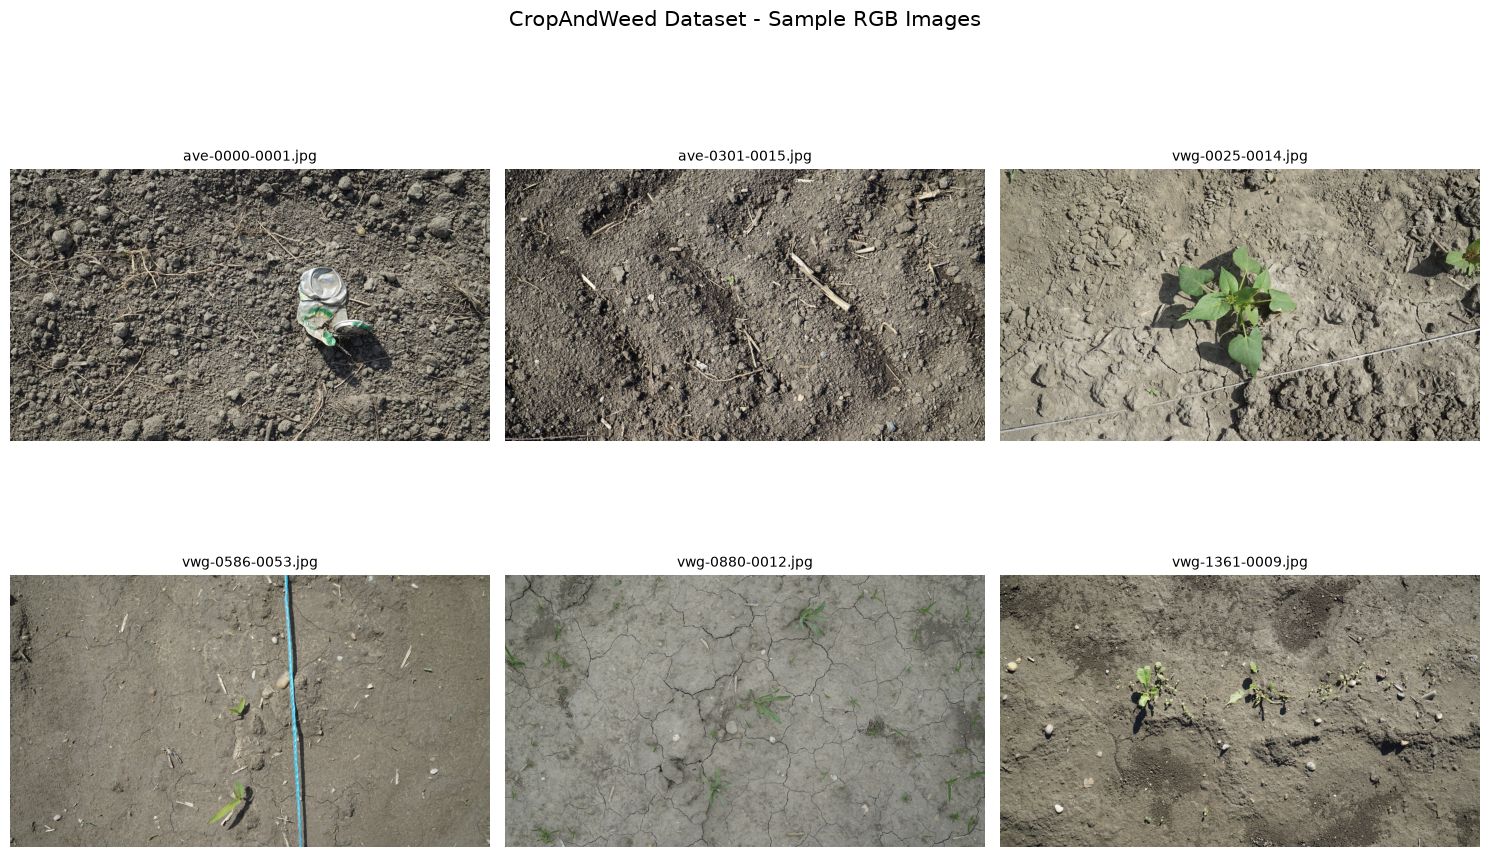

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Select six images evenly across the dataset
sample_indices = np.linspace(
    0,
    len(image_files) - 1,
    6,
    dtype=int
)

print("Selected indices:", sample_indices)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, idx in zip(axes.flatten(), sample_indices):
    image_path = image_files[idx]

    img = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img_rgb)
    ax.set_title(image_path.name, fontsize=10)
    ax.axis("off")

plt.suptitle(
    "CropAndWeed Dataset - Sample RGB Images",
    fontsize=15
)

plt.tight_layout()
plt.show()

#### Observation

- 전체 **8,034장의 RGB Image(원본 이미지)**는 모두 **1920 × 1088**의 동일한 Image Resolution(이미지 해상도)을 가지며, **3-channel** 이미지로 구성되어 있다.
- 모든 이미지를 OpenCV로 정상적으로 불러올 수 있어 Unreadable Image(읽기 불가능 이미지)는 확인되지 않았다.
- 이미지는 `uint8` 데이터 형식을 사용하며, Sample Image(샘플 이미지)의 Pixel Value(픽셀 값)는 **0–255** 범위로 확인되었다.
- Sample Image를 시각적으로 점검한 결과, 식물의 크기와 밀집도에 상당한 차이가 있으며 매우 작은 식물부터 비교적 큰 식물까지 다양한 형태가 존재한다.
- Background(배경)는 토양, 자갈, 식물 잔해, 갈라진 지면 등으로 구성되어 있으며 일부 이미지에서는 관개선 및 인공물도 관찰된다.
- 촬영 환경에 따라 강한 햇빛과 그림자가 나타나며, 식물과 배경 사이의 Contrast(대비)에도 차이가 존재한다.
- 이러한 **Object Size(객체 크기), Background Complexity(배경 복잡도), Shadow(그림자), Plant Density(식물 밀집도)** 차이는 이후 Segmentation Labeling(분할 라벨링)과 Auto Labeling(자동 라벨링)의 난이도 및 성능에 영향을 줄 수 있는 주요 요인으로 판단된다.